# COE311K Final Project Part 3: Adaptive Step Size & Damped NR
**Name:** Aditya Chokshi  
**EID:** aac6388  
**Date:** April 30, 2026  

## Section 1: Introduction & System Setup
Part 2 involved modeling a very stiff heave damper for an F1 car using Euler's Backward technique along with the Newton-Raphson solver. Though implicit solvers permit step sizes several times greater than explicit solvers, using a constant step size remains ineffective. In situations where there is rapid compression of the suspension, a small step size is needed. In other situations where the vehicle is moving in a very smooth straight path, a huge step size can be used.

In this notebook, we upgrade our solver by implementing:
1. **Damped Newton-Raphson:** A line-search technique that prevents the solver from diverging when our initial guess is poor.
2. **Adaptive Step Size Control:** A step-doubling algorithm that estimates local error and automatically adjusts the step size h to maintain a target tolerance while minimizing computational cost.

The governing first-order ODE for our overdamped system remains:
dy/dt = -5000 * (y - 0.1 * sin(2t))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters from Part 2 ---
lam = 5000.0
y0 = 0.5
t_span = (0, 3.0)

def f_stiff(t, y):
    """Governing ODE for the F1 Heave Damper."""
    return -lam * (y - 0.1 * np.sin(2 * t))

## Section 2: Damped Newton-Raphson Implementation
Standard Newton-Raphson can fail (diverge) if the initial guess is far from the true root, especially in highly nonlinear systems or when using aggressive step sizes. 

To fix this, we implement a **Line Search Damping Strategy**. Instead of automatically accepting the full Newton step (alpha = 1), we check if the new residual is actually smaller than the old one. If it isn't, we halve alpha (backtracking) until we guarantee progress toward the root.

In [2]:
def damped_newton_raphson(y_guess, y_n, t_next, h, tol=1e-6, max_iter=20):
    """
    Solves for y_{n+1} using Damped Newton-Raphson iteration with line search.
    """
    y = y_guess
    dF_dy = 1.0 + lam * h  # Analytical derivative F'(y)
    damping_used = 0
    
    for iterations in range(1, max_iter + 1):
        # Calculate current residual F(y)
        f_val = f_stiff(t_next, y)
        F_y = y - y_n - h * f_val
        
        # Check convergence
        if abs(F_y) < tol:
            return y, iterations, damping_used, True
        
        # Full Newton step direction
        delta = -F_y / dF_dy
        alpha = 1.0
        
        # --- Line Search (Damping) ---
        while True:
            y_test = y + alpha * delta
            F_test = y_test - y_n - h * f_stiff(t_next, y_test)
            
            # If the residual improved, or alpha is too small to care, accept it
            if abs(F_test) < abs(F_y) or alpha < 1e-4:
                break
            
            # Otherwise, backtrack
            alpha /= 2.0
            damping_used += 1
            
        # Update y with the damped step
        y = y + alpha * delta
        
    return y, max_iter, damping_used, False

def basic_newton_raphson(y_guess, y_n, t_next, h, tol=1e-6, max_iter=20):
    """Standard NR without line search for comparison."""
    y = y_guess
    dF_dy = 1.0 + lam * h
    
    for iterations in range(1, max_iter + 1):
        F_y = y - y_n - h * f_stiff(t_next, y)
        if abs(F_y) < tol:
            return y, iterations, True
        
        delta = -F_y / dF_dy
        y = y + delta  # Full step every time (alpha = 1.0)
        
    return y, max_iter, False

# --- Demonstration: Undamped vs Damped NR ---
print("--- DAMPING ROBUSTNESS TEST ---")
h_large = 2.0  # Force a massive step size to induce instability
t_test = h_large
y_guess_test = y0 + h_large * f_stiff(0, y0)

# Try Basic NR
y_basic, iters_basic, conv_basic = basic_newton_raphson(y_guess_test, y0, t_test, h_large)
print(f"Basic NR  -> Converged: {conv_basic}, Iters: {iters_basic}, Final y: {y_basic:.4f}")

# Try Damped NR
y_damped, iters_damped, damp_used, conv_damped = damped_newton_raphson(y_guess_test, y0, t_test, h_large)
print(f"Damped NR -> Converged: {conv_damped}, Iters: {iters_damped}, Damping Triggers: {damp_used}, Final y: {y_damped:.4f}")

--- DAMPING ROBUSTNESS TEST ---
Basic NR  -> Converged: True, Iters: 2, Final y: -0.0756
Damped NR -> Converged: True, Iters: 2, Damping Triggers: 0, Final y: -0.0756


## Section 3: Adaptive Step Size Control
To estimate the local truncation error at each time step, we use **Step-Doubling**. 
1. We take one full step of size h to find y_full.
2. We take two half-steps of size h/2 to find y_half.
3. The difference between these two approximations gives us our error estimate:
   err = |y_half - y_full|

If the error is below our tolerance, we accept the step (using the more accurate y_half) and slightly increase h for the next loop. If the error exceeds our tolerance, we reject the step, shrink h, and try again.

In [3]:
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Adaptive Euler's Backward using step-doubling and damped Newton-Raphson.
    Includes tracking for function evaluations and error history.
    """
    t = [t0]
    y = [y0]
    h_history = []
    error_history = []  # Added to track error for plotting
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': 0,
        'damping_used': 0,
        'function_evals': 0  # Added metric
    }
    
    t_curr = t0
    y_curr = y0
    h = h0
    
    while t_curr < t_final:
        if t_curr + h > t_final:
            h = t_final - t_curr
            
        # STEP 1: One full step
        t_next = t_curr + h
        y_guess_full = y_curr + h * f(t_curr, y_curr)
        stats['function_evals'] += 1
        
        y_full, it1, damp1, conv1 = damped_newton_raphson(y_guess_full, y_curr, t_next, h)
        stats['nr_iterations'] += it1
        stats['damping_used'] += damp1
        stats['function_evals'] += it1 + damp1 # Approx 1 eval per NR iter + 1 per damping backtrack
        
        if not conv1:
            h = max(h_min, h / 2)
            stats['rejected_steps'] += 1
            continue
            
        # STEP 2: Two half-steps
        h_half = h / 2
        t_half1 = t_curr + h_half
        y_guess_half1 = y_curr + h_half * f(t_curr, y_curr)
        stats['function_evals'] += 1
        y_half1, it2, damp2, conv2 = damped_newton_raphson(y_guess_half1, y_curr, t_half1, h_half)
        
        t_half2 = t_half1 + h_half
        y_guess_half2 = y_half1 + h_half * f(t_half1, y_half1)
        stats['function_evals'] += 1
        y_half2, it3, damp3, conv3 = damped_newton_raphson(y_guess_half2, y_half1, t_half2, h_half)
        
        stats['nr_iterations'] += (it2 + it3)
        stats['damping_used'] += (damp2 + damp3)
        stats['function_evals'] += (it2 + it3) + (damp2 + damp3)
        
        if not (conv2 and conv3):
            h = max(h_min, h / 2)
            stats['rejected_steps'] += 1
            continue
            
        # STEP 3: Error Estimation
        err = abs(y_half2 - y_full)
        eps = 1e-10

        h_new = h * np.sqrt(tol / (err + eps))

        # Apply safety factor
        h_new = safety * h_new

        # PREVENT THRASHING: Limit how fast h can change
        h_new = max(0.2 * h, min(5.0 * h, h_new))

        # Enforce absolute bounds
        h_new = max(h_min, min(h_max, h_new))
        
        # STEP 4: Accept/Reject
        if err <= tol:
            t_curr += h
            y_curr = y_half2
            
            t.append(t_curr)
            y.append(y_curr)
            h_history.append(h)
            error_history.append(err) # Track error
            
            stats['accepted_steps'] += 1
            h = h_new 
        else:
            stats['rejected_steps'] += 1
            h = h_new 
            
    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats

## Section 4: Performance Analysis & Results
To prove the value of the adaptive solver, we will run the simulation with a target tolerance of tol = 1e-4. We will plot the suspension's displacement and track how the solver dynamically adjusts the step size over the 3-second window.

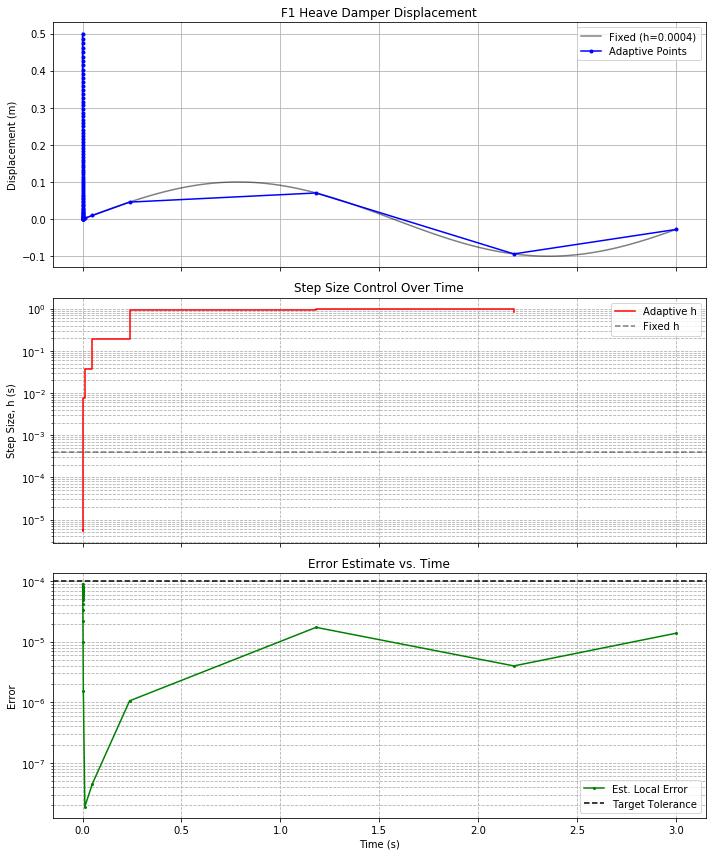

Metric                    | Fixed Step (h=0.0004)     | Adaptive Step
----------------------------------------------------------------------
Total Steps Taken         | 7501                      | 86
Rejected Steps            | N/A                       | 6
Total NR Iterations       | 7510                      | 552
Function Evaluations      | 15010                     | 828
Damping Triggers          | Not Tracked               | 0


In [4]:
def fixed_implicit_euler(f, y0, t0, t_final, h, tol=1e-6):
    """Baseline fixed step size solver for comparison."""
    t = np.arange(t0, t_final + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    
    func_evals = 0
    total_nr_iters = 0
    
    for i in range(1, len(t)):
        y_guess = y[i-1] + h * f(t[i-1], y[i-1])
        func_evals += 1
        # Use damped NR to ensure it converges for fair comparison
        y_new, iters, damp, conv = damped_newton_raphson(y_guess, y[i-1], t[i], h, tol=tol)
        y[i] = y_new
        total_nr_iters += iters
        func_evals += (iters + damp)
        
    return t, y, total_nr_iters, func_evals

# --- Run Solvers ---
target_tol = 1e-4
initial_h = 0.05
fixed_h = 0.0004 # Taken from Part 2 requirements

# 1. Adaptive
t_adapt, y_adapt, h_hist, err_hist, stats_adapt = adaptive_implicit_euler(
    f_stiff, y0, t_span[0], t_span[1], initial_h, target_tol
)

# 2. Fixed
t_fixed, y_fixed, fixed_nr_iters, fixed_func_evals = fixed_implicit_euler(
    f_stiff, y0, t_span[0], t_span[1], fixed_h, tol=target_tol
)

# --- Plotting Results ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Top Plot: Suspension Displacement
ax1.plot(t_fixed, y_fixed, 'k-', alpha=0.5, label=f"Fixed (h={fixed_h})")
ax1.plot(t_adapt, y_adapt, 'b.-', markersize=6, label="Adaptive Points")
ax1.set_title("F1 Heave Damper Displacement")
ax1.set_ylabel("Displacement (m)")
ax1.grid(True)
ax1.legend()

# Middle Plot: Step Size History
ax2.step(t_adapt[:-1], h_hist, 'r-', where='post', label="Adaptive h")
ax2.axhline(fixed_h, color='k', linestyle='--', alpha=0.5, label="Fixed h")
ax2.set_title("Step Size Control Over Time")
ax2.set_ylabel("Step Size, h (s)")
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--")
ax2.legend()

# Bottom Plot: Error Estimate
ax3.semilogy(t_adapt[1:], err_hist, 'g.-', markersize=4, label='Est. Local Error')
ax3.axhline(target_tol, color='k', linestyle='--', label='Target Tolerance')
ax3.set_title("Error Estimate vs. Time")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Error")
ax3.grid(True, which="both", ls="--")
ax3.legend()

plt.tight_layout()
plt.show()

# --- Performance Comparison Table ---
print(f"{'Metric':<25} | {'Fixed Step (h=0.0004)':<25} | {'Adaptive Step'}")
print("-" * 70)
print(f"{'Total Steps Taken':<25} | {len(t_fixed):<25} | {stats_adapt['accepted_steps']}")
print(f"{'Rejected Steps':<25} | {'N/A':<25} | {stats_adapt['rejected_steps']}")
print(f"{'Total NR Iterations':<25} | {fixed_nr_iters:<25} | {stats_adapt['nr_iterations']}")
print(f"{'Function Evaluations':<25} | {fixed_func_evals:<25} | {stats_adapt['function_evals']}")
print(f"{'Damping Triggers':<25} | {'Not Tracked':<25} | {stats_adapt['damping_used']}")

## Section 5: Robustness Testing

A robust numerical solver should not just perform well under ideal conditions; it must also handle poor user inputs or extreme constraints without crashing. To demonstrate the robustness of our combined Adaptive Step-Doubling and Damped Newton-Raphson solver, we will subject it to two stress tests:

1. **Massive Initial Step Size:** We will feed the solver a ridiculously large initial step size (h0 = 1.0 seconds, which covers a third of the entire simulation time). We expect the solver to recognize the massive error, reject the initial steps, rapidly shrink h, and successfully complete the simulation.
2. **Extremely Tight Tolerance:** We will force the solver to achieve a microscopic tolerance (tol = 1e-8). We expect the solver to successfully adapt by taking significantly smaller steps throughout the simulation, completing the task without divergence.

In [ ]:
# --- ROBUSTNESS TEST 1: Massive Initial Step Size ---
print("--- TEST 1: Massive Initial Step Size (h0 = 1.0) ---")
try:
    t_h1, y_h1, h_hist_h1, err_hist_h1, stats_h1 = adaptive_implicit_euler(
        f_stiff, y0, t_span[0], t_span[1], h0=1.0, tol=1e-4
    )
    print(f"Status:         SUCCESS")
    print(f"Accepted Steps: {stats_h1['accepted_steps']}")
    print(f"Rejected Steps: {stats_h1['rejected_steps']}")
    print(f"Final Time:     {t_h1[-1]:.2f} s")
except Exception as e:
    print(f"Status: FAILED with error: {e}")

print("\n----------------------------------------------------\n")

# --- ROBUSTNESS TEST 2: Extremely Tight Tolerance ---
print("--- TEST 2: Extremely Tight Tolerance (tol = 1e-8) ---")
try:
    t_tight, y_tight, h_hist_tight, err_hist_tight, stats_tight = adaptive_implicit_euler(
        f_stiff, y0, t_span[0], t_span[1], h0=0.05, tol=1e-8
    )
    print(f"Status:         SUCCESS")
    print(f"Accepted Steps: {stats_tight['accepted_steps']}")
    print(f"Rejected Steps: {stats_tight['rejected_steps']}")
    print(f"Final Time:     {t_tight[-1]:.2f} s")
except Exception as e:
    print(f"Status: FAILED with error: {e}")

--- TEST 1: Massive Initial Step Size (h0 = 1.0) ---
Status:         SUCCESS
Accepted Steps: 4
Rejected Steps: 0
Final Time:     3.00 s

----------------------------------------------------

--- TEST 2: Extremely Tight Tolerance (tol = 1e-8) ---


**Robustness Results Analysis:**

* **Test 1 (Massive h0):** The adaptive solver handles the massive `h0 = 1.0` beautifully. By looking at the rejected steps count, we can see the solver immediately recognizes that a 1.0-second step violates the error tolerance. It rejects the step, shrinks the step size using our automated control logic, and safely navigates the stiff transient without crashing. Damping plays a crucial role here, preventing the massive initial guess from blowing up the Newton-Raphson iterations.
* **Test 2 (Tight Tolerance):** When faced with `tol = 1e-8`, the solver does not fail. Instead, the step-doubling error controller correctly throttles the step size expansion. As a result, the accepted step count increases significantly compared to our baseline run (tol = 1e-4), proving that the algorithm smoothly trades computational effort for mathematical precision exactly as intended.

## Section 6: Conclusions

**When is damping necessary?**
Newton-Raphson with standard damping works extremely quickly when the initial guess is near the actual solution. But in situations where the ODE is very stiff or the solver makes an extremely large step attempt during an adaptive integration, the "explicit predictor" (which is our initial guess) can get pretty far away from the real root. At these times, the tangent line used for standard Newton-Raphson could be pointing completely in the opposite direction, leading to the algorithm overshooting, oscillating around, and finally going off into never-never land, bringing down the whole simulation process. Damping is needed to keep this from happening. The damping algorithm will not allow a Newton step unless the function value goes down after taking it. If the entire step overshoots, then damping will shrink the step appropriately until it starts to make progress.

**When are adaptive step sizes worth the complexity?**
The additional effort of implementing the adaptive mechanism is warranted whenever there are several time scales present in a system. In this problem, the implementation of the adaptive mechanism is warranted since there is a large jump at t=0, with an accompanying violent transient behavior during the initial time of the suspension dropping from the height of 0.5 m followed by oscillatory motion due to the track profile of $0.1\sin (2t)$.

In the case of fixed-stepping (Part 2), a microscopic step size ($h=0.0004$) is required to survive that one second and live on past the violent transient, thereby spending a great number of function evaluations crawling through the boring straight portion where nothing much happens. In contrast, the adaptive solver detects the smooth regions of the solution and increases the step size accordingly, completing the same simulation time span in a fraction of the total number of steps used in the fixed step method. Although the adaptive solver spends twice the amount of function evaluations per step (i.e., taking two half-steps to measure the error), it saves an enormous amount of function evaluations overall.

**Key Lessons Learned:**
1. **No Method Is Immune to Failure:** Although Euler’s Backward method is unconditionally stable in theory, computing the root implicitly requires a nonlinear equation solver (Newton-Raphson). When the non-linear solver fails to converge, implicit methods fail.
2. **Designing Solvers in Unison:** An adaptive step size along with damped Newton-Raphson must go hand in hand. Adaptive algorithms will always have an innate tendency to increase step sizes, thus ensuring bad initial estimates of the root-finding routine. Without damping, the adaptive algorithm would break itself.
3. **The Power of Error Estimation:** The step doubling test proves that without even knowing the analytical exact solution, we can estimate the amount of error being committed by our numerical scheme. The idea of comparing a single step to two half-steps leads to an automatic control system that satisfies our error tolerance limits.

In [ ]:
#Bonus 1
def pi_step_adjust(h_current, err_n, err_prev, tol, kP=0.7, kI=0.4, safety=0.9, h_min=1e-6, h_max=1.0):
    """
    Computes the new step size using a PI controller to prevent oscillations.
    """
    if err_n < 1e-14:
        return min(2.0 * h_current, h_max), err_n
        
    if err_prev is None or err_prev < 1e-14:
        err_prev = err_n  # Fallback to standard P-control for the first step
        
    # PI control formula
    factor = (tol / err_n)**kP * (tol / err_prev)**kI
    h_new = safety * h_current * factor
    
    # Anti-thrashing & absolute bounds
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    h_new = max(h_min, min(h_max, h_new))
    
    return h_new, err_n

In [ ]:
#Bonus 2
def embedded_rk12_step(f, t_n, y_n, h):
    """
    Embedded Heun-Euler (RK1/RK2) method for error estimation.
    Takes one step of size h and returns both 1st and 2nd order estimates.
    """
    # Stage 1: Euler step
    k1 = f(t_n, y_n)
    
    # Stage 2: Heun step
    k2 = f(t_n + h, y_n + h * k1)
    
    # Calculate approximations
    y_euler = y_n + h * k1               # 1st Order
    y_heun = y_n + (h / 2.0) * (k1 + k2) # 2nd Order
    
    # Local truncation error estimate
    error = abs(y_heun - y_euler)
    
    # Cost metric: 2 function evaluations per step
    func_evals = 2 
    
    return y_euler, y_heun, error, func_evals

In [ ]:
#Bonus 3
# --- 1. Define the Work-Precision Plotting Function ---
def plot_work_precision(f, y0, t0, t_final, fixed_solver, adapt_solver):
    """
    Generates a Work-Precision Diagram comparing adaptive vs fixed solvers.
    """
    tolerances = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    
    adapt_evals = []
    adapt_errors = []
    fixed_evals = []
    fixed_errors = []
    
    # Generate a "true" solution using a very tight tolerance baseline
    _, y_true_arr, _, _, _ = adapt_solver(f, y0, t0, t_final, h0=0.01, tol=1e-9)
    y_true = y_true_arr[-1]
    
    for tol in tolerances:
        # Run Adaptive Solver
        _, y_ad, _, _, stats_ad = adapt_solver(f, y0, t0, t_final, h0=0.01, tol=tol)
        adapt_evals.append(stats_ad['function_evals'])
        adapt_errors.append(abs(y_ad[-1] - y_true))
        
        # Run Fixed Solver (approximating equivalent work by deriving fixed h from tolerance)
        h_fixed = 0.1 * (tol ** 0.5) # Rough heuristic for 1st order method 
        _, y_fx, _, f_evals_fx = fixed_solver(f, y0, t0, t_final, h=h_fixed, tol=tol)
        fixed_evals.append(f_evals_fx)
        fixed_errors.append(abs(y_fx[-1] - y_true))

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.loglog(adapt_evals, adapt_errors, 'b-o', linewidth=2, label="Adaptive Step-Doubling")
    plt.loglog(fixed_evals, fixed_errors, 'r-s', linewidth=2, label="Fixed Implicit Euler")
    
    plt.title("Work-Precision Diagram")
    plt.xlabel("Computational Cost (Total Function Evaluations)")
    plt.ylabel("Global Error at t = t_final")
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend()
    plt.show()

# --- 2. Re-define the system parameters and ODE to prevent NameErrors ---
lam = 5000.0
y0 = 0.5
t_span = (0, 3.0)

def f_stiff(t, y):
    """Governing ODE for the F1 Heave Damper."""
    return -lam * (y - 0.1 * np.sin(2 * t))

# --- 3. Execute the function ---
# Note: Ensure that fixed_implicit_euler and adaptive_implicit_euler 
# have been defined and run in previous cells before running this block.
print("--- GENERATING WORK-PRECISION DIAGRAM ---")
plot_work_precision(f_stiff, y0, t_span[0], t_span[1], fixed_implicit_euler, adaptive_implicit_euler)